In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

In [3]:
M = 15*15 * 4

es = 0.1
er = 0.9

Is = 0.0100
Ic = 0.0100
m  = 0.0050
k  = 0.0005

r  = 0.015
c  = 1.000

def nr(v):
    return (  ( 1 - ( m*er + k*v*v )/(Is*c) ) * r/Is  )

def ns(v):
    return (  ( 1 - ( m*es + k*v*v )/(Is*c) ) * r/Is  )

In [4]:
nD = 5
nN = 45

In [5]:
Files = []

for i in range(nD):  
    File = []
    for j in range(61):  
        filename = f'population_{i}_{j:02}.txt'
        File.append(filename)

    Files.append(File)

In [6]:
ts = []
Ns = []
As = []
Es = []
Ps = []
Qs = []
Ss = []

for i in range(nD):  

    t = []
    N = []
    A = []
    E = []
    P = []
    Q = []
    S = []
    
    for j in range(nN):
        
        file=open(Files[i][j],'r')
        content=file.readlines()

        datos1=[]
        datos2=[]
        datos3=[]
        datos4=[]
        datos5=[]
        datos6=[]
        datos7=[]

        for ii in range (0,len(content),1):
           dato1  = content[ii].find(' ')
           dato2  = content[ii].find(' ', dato1  + 1)
           dato3  = content[ii].find(' ', dato2  + 1)
           dato4  = content[ii].find(' ', dato3  + 1)
           dato5  = content[ii].find(' ', dato4  + 1)
           dato6  = content[ii].find(' ', dato5  + 1)
           dato7  = content[ii].find(' ', dato6  + 1)

           valor1  = float(content[ii][         0 : dato1 ])
           valor2  = float(content[ii][dato1  + 1 : dato2 ])
           valor3  = float(content[ii][dato2  + 1 : dato3 ])
           valor4  = float(content[ii][dato3  + 1 : dato4 ])
           valor5  = float(content[ii][dato4  + 1 : dato5 ])
           valor6  = float(content[ii][dato5  + 1 : dato6 ])
           valor7  = float(content[ii][dato6  + 1 : dato7 ])

           datos1.append(valor1)
           datos2.append(valor2/M)
           datos3.append(valor3)
           datos4.append(valor4)
           datos5.append(valor5)
           datos6.append(valor6)
           datos7.append(valor7)

        t.append(datos1)
        N.append(datos2)
        A.append(datos3)
        E.append(datos4)
        P.append(datos5)
        Q.append(datos6)
        S.append(datos7)

    ts.append(t)
    Ns.append(N)
    As.append(A)
    Es.append(E)
    Ps.append(P)
    Qs.append(Q)
    Ss.append(S)

In [7]:
# PARISA
#colors = [(0, 0, 0), (0, 0, 1), (0, 0.541176471, 0),(1.0, 0.505882353, 0.0), (1, 0, 0)]
#cmap_name = 'my_list'
#n_bin=1000000
#cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bin)

colors = ['indigo', 'blue', 'limegreen', 'gold', 'red']
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

In [53]:
iD = 4

D = 10**(iD+1.0)
v = 0.1*(2.0*D)**(1.0/3.0)

nf = 0
for i in range(nN):
    if Ns[iD][i][-1] > 0:
        nf = i

norm = Normalize(vmin=0, vmax=nf+10)

color = []
for i in range(nN):
    if Ns[iD][i][-1] == 0:
        color.append('red')
    else:
        color.append(cmap(norm(i)))

print(nf)

0


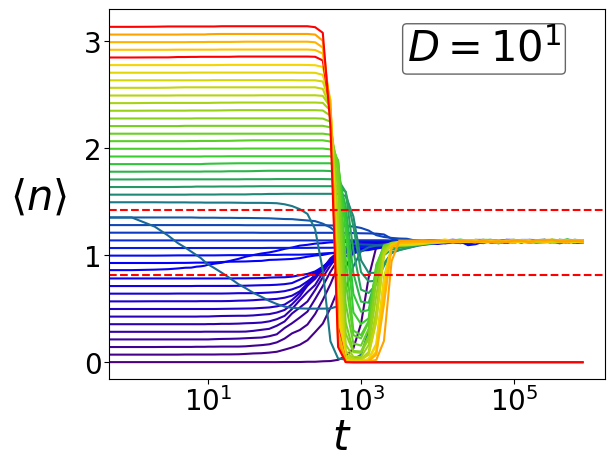

In [9]:
fig, ax = plt.subplots()

ax.text(0.60, 0.95, r'$D = 10^{1}$', fontsize=30, transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))

ax.text(0.45, -0.10, r'$t$', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.20, 0.55, r'$ \langle n \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')


ax.tick_params(labelsize=20, direction='out', pad=2)
ax.set_xscale('log')

ax.set_xticks([1e1, 1e3, 1e5])
ax.set_yticks([-1, 0, 1, 2, 3])

for i in range(min(nf+5,nN)):
    
    plt.plot(ts[iD][i], Ns[iD][i], color=color[i])

plt.axhline(y=nr(v), color='red', linestyle='--')
plt.axhline(y=ns(v), color='red', linestyle='--')

plt.savefig(f'nvst_{iD}.pdf', format="pdf", transparent=True, bbox_inches="tight")
plt.show()

In [54]:
nis = []
nfs = []

for i in range(nN):
    nis.append(Ns[iD][i][0])
    nfs.append(np.mean(Ns[iD][i][40:]))

In [42]:
nfs[41] = 0
nfs[42] = 0
nfs[43] = 0
nfs[44] = 0

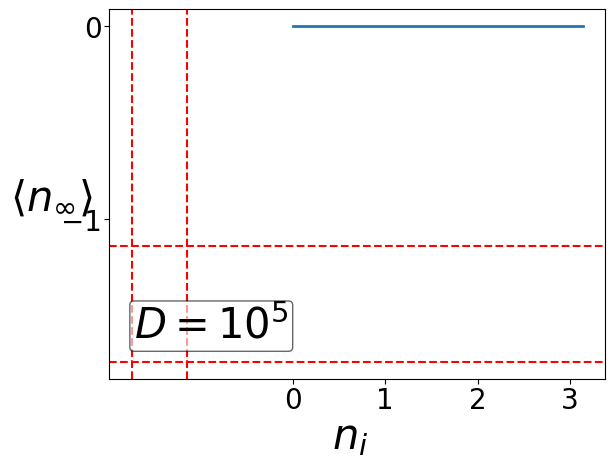

In [55]:
fig, ax = plt.subplots()

ax.text(0.05, 0.20, r'$D = 10^{5}$', fontsize=30, transform=ax.transAxes,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.1'))

ax.text(0.45, -0.10, r'$ n_i $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')
ax.text(-0.20, 0.55, r'$  \langle n_\infty \rangle $', fontsize=30, fontweight='bold', transform=ax.transAxes,
         verticalalignment='top')

ax.tick_params(labelsize=20, direction='out', pad=2)

ax.set_xticks([0, 1, 2, 3])
ax.set_yticks([-1, 0, 1, 2, 3])
  
plt.plot(nis, nfs, lw=2)

plt.axhline(y=nr(v), color='red', linestyle='--')
plt.axhline(y=ns(v), color='red', linestyle='--')
plt.axvline(x=nr(v), color='red', linestyle='--')
plt.axvline(x=ns(v), color='red', linestyle='--')

plt.savefig(f'nfvsni_{iD}.pdf', format="pdf", transparent=True, bbox_inches="tight")
plt.show()